# Raw-Feature TFT Transfer Learning for Battery RUL

This notebook runs raw-feature Temporal Fusion Transformer transfer learning in both directions:

1. NASA -> HNEI
2. HNEI -> NASA

For each direction it trains a source TFT, evaluates source test and target zero-shot performance, fine-tunes on target batteries, and trains a matched target-only baseline on the same target batteries. The model input is limited to the 7 raw cycle-level feature columns; `time_idx` is used only as the sequence index.

In [1]:
# If the imports below fail, uncomment and run this cell once.
# %pip install -q lightning pytorch-forecasting

In [2]:
from pathlib import Path
import math
import os
import random

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/dlproj_matplotlib_cache").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str(Path("/tmp/dlproj_xdg_cache").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["XDG_CACHE_HOME"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import RMSE
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import matplotlib.pyplot as plt

SEED = 42
seed_everything(SEED, workers=True)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

Matplotlib is building the font cache; this may take a moment.
Seed set to 42


Using device: mps


In [3]:
HNEI_DATA_PATH = Path("Battery_RUL_Cleaned.csv")
NASA_DATA_PATH = Path("nasa_battery_cycles.csv")
DATA_PATHS = {"hnei": HNEI_DATA_PATH, "nasa": NASA_DATA_PATH}
CHECKPOINT_ROOT = Path("model_checkpoints")
FIGURE_DIR = Path("figures")
METRICS_CSV = Path("tft_raw_transfer_results.csv")
PREDICTIONS_CSV = Path("tft_raw_prediction_rows.csv")
MODEL_TARGET_COL = "target_scaled"

RENAMES = {
    "Cycle_Index": "time_idx",
    "Discharge Time (s)": "discharge_time",
    "Decrement 3.6-3.4V (s)": "decrement_36_34",
    "Max. Voltage Dischar. (V)": "max_voltage_discharge",
    "Min. Voltage Charg. (V)": "min_voltage_charge",
    "Time at 4.15V (s)": "time_at_415",
    "Time constant current (s)": "time_constant_current",
    "Charging time (s)": "charging_time",
    "RUL": "target",
}

RAW_FEATURE_COLS = [
    "discharge_time",
    "decrement_36_34",
    "max_voltage_discharge",
    "min_voltage_charge",
    "time_at_415",
    "time_constant_current",
    "charging_time",
]

MAX_ENCODER_LENGTH = 10
MAX_PREDICTION_LENGTH = 1
TFT_BATCH_SIZE = 64
TFT_SOURCE_EPOCHS = 15
TFT_TRANSFER_EPOCHS = 6
TFT_TARGET_ONLY_EPOCHS = 20
TFT_SOURCE_LR = 3e-2
TFT_TRANSFER_LR = 1e-4
TFT_HIDDEN_SIZE = 16
TFT_DROPOUT = 0.2
TARGET_TRAIN_FRACTION = 0.35
CLIP_NEGATIVE_RUL_PREDICTIONS = True
FINETUNE_MODE = "head_only"

DIRECTIONS = [("nasa", "hnei"), ("hnei", "nasa")]

## Load Separate Battery Datasets

HNEI is loaded from `Battery_RUL_Cleaned.csv` and NASA is loaded from `nasa_battery_cycles.csv`. Battery IDs are constructed from cycle-index resets within each file, then prefixed by domain so IDs stay unique after concatenation.

In [4]:
def load_domain_data(path: Path, domain: str) -> pd.DataFrame:
    data = pd.read_csv(path).rename(columns=RENAMES).reset_index(drop=True)
    required_cols = ["time_idx", "target"] + RAW_FEATURE_COLS
    missing = sorted(set(required_cols) - set(data.columns))
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")

    data["battery_number"] = (data["time_idx"] == 1).cumsum() - 1
    data["battery_id"] = data["battery_number"].map(lambda value: f"{domain}_{int(value):02d}")
    data["domain"] = domain
    data = data.sort_values(["battery_id", "time_idx"]).reset_index(drop=True)
    data["battery_id"] = data["battery_id"].astype(str)
    data["time_idx"] = data["time_idx"].astype(int)
    data["target"] = data["target"].astype(float)
    return data[["domain", "battery_id", "time_idx", "target"] + RAW_FEATURE_COLS]


domain_frames = [load_domain_data(path, domain) for domain, path in DATA_PATHS.items()]
df = pd.concat(domain_frames, ignore_index=True)

print(df.shape)
print(df.groupby("domain")["battery_id"].nunique())
display(df.head())

(17658, 11)
domain
hnei    14
nasa    34
Name: battery_id, dtype: int64


,domain,battery_id,time_idx,target,discharge_time,decrement_36_34,max_voltage_discharge,min_voltage_charge,time_at_415,time_constant_current,charging_time
0,hnei,hnei_00,1,1062.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82
1,hnei,hnei_00,2,1061.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35
2,hnei,hnei_00,3,1060.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38
3,hnei,hnei_00,4,1059.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81
4,hnei,hnei_00,5,1058.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65


## Splits And Leakage-Safe Scaling

Splits are made at battery level. One last battery per domain is reserved for simulation-style holdout, and feature/target scalers are fit only on the training batteries used by each experiment path.

In [5]:
def split_domain_by_battery(
    data: pd.DataFrame,
    domain: str,
    test_size: float = 0.20,
    val_size_of_remaining: float = 0.20,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    domain_df = data[data["domain"] == domain].copy()
    battery_ids = np.array(sorted(domain_df["battery_id"].unique()))

    train_val_ids, test_ids = train_test_split(
        battery_ids, test_size=test_size, random_state=seed, shuffle=True
    )
    train_ids, val_ids = train_test_split(
        train_val_ids, test_size=val_size_of_remaining, random_state=seed, shuffle=True
    )

    train_df = domain_df[domain_df["battery_id"].isin(train_ids)].copy()
    val_df = domain_df[domain_df["battery_id"].isin(val_ids)].copy()
    test_df = domain_df[domain_df["battery_id"].isin(test_ids)].copy()
    return train_df, val_df, test_df


def keep_fraction_of_batteries(
    domain_train_df: pd.DataFrame,
    fraction: float,
    seed: int = SEED,
) -> pd.DataFrame:
    if fraction >= 1.0:
        return domain_train_df.copy()
    battery_ids = np.array(sorted(domain_train_df["battery_id"].unique()))
    n_keep = max(1, math.ceil(len(battery_ids) * fraction))
    rng = np.random.default_rng(seed)
    keep_ids = rng.choice(battery_ids, size=n_keep, replace=False)
    return domain_train_df[domain_train_df["battery_id"].isin(keep_ids)].copy()


def battery_numeric_suffix(battery_id: str) -> int:
    return int(str(battery_id).split("_")[-1])


def get_last_battery_id(data: pd.DataFrame, domain: str) -> str:
    ids = sorted(data.loc[data["domain"] == domain, "battery_id"].unique(), key=battery_numeric_suffix)
    if not ids:
        raise ValueError(f"No batteries found for domain={domain!r}")
    return ids[-1]


def remove_batteries(data: pd.DataFrame, battery_ids: set[str]) -> pd.DataFrame:
    return data[~data["battery_id"].isin(battery_ids)].copy()


def build_feature_scaler(fit_df: pd.DataFrame, feature_cols: list[str], label: str) -> dict[str, object]:
    means = fit_df[feature_cols].mean().astype(float)
    stds = fit_df[feature_cols].std(ddof=0).replace(0, 1.0).astype(float)
    return {
        "label": label,
        "feature_cols": tuple(feature_cols),
        "mean": means.to_dict(),
        "std": stds.to_dict(),
        "fit_battery_ids": tuple(sorted(fit_df["battery_id"].astype(str).unique())),
        "fit_rows": int(len(fit_df)),
    }


def apply_feature_scaler(data: pd.DataFrame, scaler: dict[str, object]) -> pd.DataFrame:
    result = data.copy()
    for col in scaler["feature_cols"]:
        result[col] = (result[col] - scaler["mean"][col]) / scaler["std"][col]
    return result


def build_target_scaler(fit_df: pd.DataFrame, label: str) -> dict[str, object]:
    target_min = float(fit_df["target"].min())
    target_max = float(fit_df["target"].max())
    if target_max <= target_min:
        raise ValueError(f"Invalid target range for {label}: {target_min}, {target_max}")
    return {
        "label": label,
        "target_min": target_min,
        "target_max": target_max,
        "target_range": target_max - target_min,
        "fit_battery_ids": tuple(sorted(fit_df["battery_id"].astype(str).unique())),
        "fit_rows": int(len(fit_df)),
    }


def add_normalized_columns(data: pd.DataFrame, scaler: dict[str, object]) -> pd.DataFrame:
    result = data.copy()
    result[MODEL_TARGET_COL] = (result["target"] - scaler["target_min"]) / scaler["target_range"]
    return result


def inverse_target_scale(values_scaled: np.ndarray, scaler: dict[str, object]) -> np.ndarray:
    return values_scaled * scaler["target_range"] + scaler["target_min"]


def battery_id_set(data: pd.DataFrame) -> set[str]:
    return set(data["battery_id"].astype(str).unique())


def assert_disjoint_batteries(label: str, *parts: tuple[str, pd.DataFrame]) -> None:
    seen: dict[str, set[str]] = {}
    for name, part in parts:
        ids = battery_id_set(part)
        for other_name, other_ids in seen.items():
            overlap = ids & other_ids
            if overlap:
                raise AssertionError(
                    f"Battery leakage in {label}: {name} overlaps {other_name}: {sorted(overlap)}"
                )
        seen[name] = ids
    counts = ", ".join(f"{name}={len(ids)}" for name, ids in seen.items())
    print(f"Leakage check passed for {label}: {counts}")


def assert_no_simulation_batteries(label: str, *parts: tuple[str, pd.DataFrame]) -> None:
    sim_ids = set(simulation_battery_ids.values())
    for name, part in parts:
        overlap = battery_id_set(part) & sim_ids
        if overlap:
            raise AssertionError(f"Simulation battery leakage in {label}: {name} contains {sorted(overlap)}")
    print(f"Simulation exclusion check passed for {label}: excluded={sorted(sim_ids)}")


def assert_target_scaler_from_training_only(
    label: str,
    scaler: dict[str, object],
    fit_df: pd.DataFrame,
    *forbidden_parts: tuple[str, pd.DataFrame],
) -> None:
    expected_ids = tuple(sorted(fit_df["battery_id"].astype(str).unique()))
    if tuple(scaler["fit_battery_ids"]) != expected_ids:
        raise AssertionError(f"Scaler {label} was not fit on the expected training batteries")
    if not np.isclose(float(scaler["target_min"]), float(fit_df["target"].min())):
        raise AssertionError(f"Scaler {label} target_min does not match training data")
    if not np.isclose(float(scaler["target_max"]), float(fit_df["target"].max())):
        raise AssertionError(f"Scaler {label} target_max does not match training data")
    fit_ids = set(expected_ids)
    for name, part in forbidden_parts:
        overlap = fit_ids & battery_id_set(part)
        if overlap:
            raise AssertionError(f"Scaler {label} fit batteries overlap forbidden {name}: {sorted(overlap)}")
    print(
        f"Scaler check passed for {label}: fit_rows={scaler['fit_rows']}, "
        f"fit_batteries={list(expected_ids)}, "
        f"range=[{scaler['target_min']:.2f}, {scaler['target_max']:.2f}]"
    )


def assert_feature_scaler_from_training_only(
    label: str,
    scaler: dict[str, object],
    fit_df: pd.DataFrame,
    *forbidden_parts: tuple[str, pd.DataFrame],
) -> None:
    expected_ids = tuple(sorted(fit_df["battery_id"].astype(str).unique()))
    if tuple(scaler["fit_battery_ids"]) != expected_ids:
        raise AssertionError(f"Feature scaler {label} was not fit on the expected training batteries")
    for col in scaler["feature_cols"]:
        if not np.isclose(float(scaler["mean"][col]), float(fit_df[col].mean())):
            raise AssertionError(f"Feature scaler {label} mean mismatch for {col}")
        expected_std = float(fit_df[col].std(ddof=0)) or 1.0
        if not np.isclose(float(scaler["std"][col]), expected_std):
            raise AssertionError(f"Feature scaler {label} std mismatch for {col}")
    fit_ids = set(expected_ids)
    for name, part in forbidden_parts:
        overlap = fit_ids & battery_id_set(part)
        if overlap:
            raise AssertionError(f"Feature scaler {label} fit batteries overlap forbidden {name}: {sorted(overlap)}")
    print(
        f"Feature scaler check passed for {label}: fit_rows={scaler['fit_rows']}, "
        f"fit_batteries={list(expected_ids)}"
    )


simulation_battery_ids = {
    domain: get_last_battery_id(df, domain)
    for domain in ["hnei", "nasa"]
}
simulation_battery_id_set = set(simulation_battery_ids.values())
simulation_sets = {
    domain: df[df["battery_id"] == battery_id].copy()
    for domain, battery_id in simulation_battery_ids.items()
}

raw_splits = {
    domain: split_domain_by_battery(df, domain)
    for domain in ["hnei", "nasa"]
}
splits = {
    domain: tuple(remove_batteries(part, simulation_battery_id_set) for part in parts)
    for domain, parts in raw_splits.items()
}

print("Reserved simulation batteries:")
for domain, battery_id in simulation_battery_ids.items():
    sim = simulation_sets[domain]
    print(
        f"  {domain.upper()}: {battery_id}, rows={len(sim)}, "
        f"cycles=[{sim['time_idx'].min()}, {sim['time_idx'].max()}], "
        f"RUL=[{sim['target'].min():.1f}, {sim['target'].max():.1f}]"
    )

print("\nModeling splits after simulation holdout:")
for domain, (train_df, val_df, test_df) in splits.items():
    assert_disjoint_batteries(
        f"{domain} train/val/test",
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
        ("simulation", simulation_sets[domain]),
    )
    assert_no_simulation_batteries(
        f"{domain} modeling splits",
        ("train", train_df),
        ("val", val_df),
        ("test", test_df),
    )
    print(f"{domain.upper()}")
    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df), ("simulation", simulation_sets[domain])]:
        print(
            f"  {split_name:10s}: rows={len(split_df):5d}, batteries={split_df['battery_id'].nunique():2d}, "
            f"ids={sorted(split_df['battery_id'].unique())}"
        )

Reserved simulation batteries:
  HNEI: hnei_13, rows=1039, cycles=[1, 1039], RUL=[0.0, 1038.0]
  NASA: nasa_33, rows=102, cycles=[1, 102], RUL=[0.0, 101.0]

Modeling splits after simulation holdout:
Leakage check passed for hnei train/val/test: train=8, val=2, test=3, simulation=1
Simulation exclusion check passed for hnei modeling splits: excluded=['hnei_13', 'nasa_33']
HNEI
  train     : rows= 8516, batteries= 8, ids=['hnei_01', 'hnei_02', 'hnei_04', 'hnei_05', 'hnei_06', 'hnei_07', 'hnei_08', 'hnei_10']
  val       : rows= 2124, batteries= 2, ids=['hnei_03', 'hnei_12']
  test      : rows= 3195, batteries= 3, ids=['hnei_00', 'hnei_09', 'hnei_11']
  simulation: rows= 1039, batteries= 1, ids=['hnei_13']
Leakage check passed for nasa train/val/test: train=20, val=6, test=7, simulation=1
Simulation exclusion check passed for nasa modeling splits: excluded=['hnei_13', 'nasa_33']
NASA
  train     : rows= 1406, batteries=20, ids=['nasa_00', 'nasa_01', 'nasa_04', 'nasa_05', 'nasa_06', 'nasa_

## TFT Helpers

The TFT predicts normalized RUL (`target_scaled`). Raw features are the only time-varying input values, while `time_idx` remains the sequence index and is not included as a known real feature.

In [6]:
def attach_prediction_index(dataset: TimeSeriesDataSet, data: pd.DataFrame) -> TimeSeriesDataSet:
    group_order = list(data.groupby("battery_id", sort=False).groups.keys())
    index = dataset.index.copy().reset_index(drop=True)
    prediction_index = pd.DataFrame({
        "battery_id": index["sequence_id"].map(lambda value: str(group_order[int(value)])),
        "time_idx": (index["time"] + index["sequence_length"] - dataset.max_prediction_length).astype(int),
    })
    dataset.prediction_index_ = prediction_index
    return dataset


def make_tft_datasets(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> tuple[TimeSeriesDataSet, TimeSeriesDataSet, TimeSeriesDataSet]:
    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=MODEL_TARGET_COL,
        group_ids=["battery_id"],
        categorical_encoders={
            "battery_id": NaNLabelEncoder(add_nan=True),
            "__group_id__battery_id": NaNLabelEncoder(add_nan=True),
        },
        min_encoder_length=1,
        max_encoder_length=MAX_ENCODER_LENGTH,
        min_prediction_length=MAX_PREDICTION_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=[],
        static_reals=[],
        time_varying_known_reals=[],
        time_varying_unknown_reals=RAW_FEATURE_COLS,
        add_relative_time_idx=True,
        add_target_scales=False,
        add_encoder_length=True,
        target_normalizer=None,
        allow_missing_timesteps=True,
    )
    validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=False, stop_randomization=True)
    test = TimeSeriesDataSet.from_dataset(training, test_df, predict=False, stop_randomization=True)
    attach_prediction_index(training, train_df)
    attach_prediction_index(validation, val_df)
    attach_prediction_index(test, test_df)
    if "time_idx" in training.reals:
        raise AssertionError("time_idx is present in TFT real-valued inputs")
    return training, validation, test


def make_transfer_dataset(source_training: TimeSeriesDataSet, target_df: pd.DataFrame) -> TimeSeriesDataSet:
    dataset = TimeSeriesDataSet.from_dataset(source_training, target_df, predict=False, stop_randomization=True)
    attach_prediction_index(dataset, target_df)
    if "time_idx" in dataset.reals:
        raise AssertionError("time_idx is present in TFT real-valued inputs")
    return dataset


def make_dataloader(dataset: TimeSeriesDataSet, train: bool) -> DataLoader:
    return dataset.to_dataloader(train=train, batch_size=TFT_BATCH_SIZE, num_workers=0)


def print_tft_sample_shape(dataset: TimeSeriesDataSet, label: str) -> None:
    x, y = dataset[0]
    y_tensor = y[0] if isinstance(y, tuple) else y
    print(
        f"{label} sample: x_cont_shape={tuple(x['x_cont'].shape)}, "
        f"encoder_length={int(x['encoder_length'])}, decoder_length={int(x['decoder_length'])}, "
        f"target_shape={tuple(y_tensor.shape)}, reals={dataset.reals}"
    )


def build_tft(training: TimeSeriesDataSet, learning_rate: float) -> TemporalFusionTransformer:
    return TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=learning_rate,
        hidden_size=TFT_HIDDEN_SIZE,
        attention_head_size=2,
        dropout=TFT_DROPOUT,
        hidden_continuous_size=8,
        output_size=1,
        loss=RMSE(),
        reduce_on_plateau_patience=3,
    )


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def configure_tft_finetuning(model: TemporalFusionTransformer, mode: str = FINETUNE_MODE) -> TemporalFusionTransformer:
    if mode == "all":
        for param in model.parameters():
            param.requires_grad = True
    elif mode == "head_only":
        for param in model.parameters():
            param.requires_grad = False
        trainable = 0
        for name, param in model.named_parameters():
            if "output_layer" in name:
                param.requires_grad = True
                trainable += param.numel()
        if trainable == 0:
            print("No output_layer parameters found; falling back to full TFT fine-tuning.")
            for param in model.parameters():
                param.requires_grad = True
    else:
        raise ValueError(f"Unsupported FINETUNE_MODE={mode!r}")
    print(f"Fine-tuning mode={mode}; trainable parameters={count_trainable_parameters(model):,}")
    return model


def fit_tft(
    model: TemporalFusionTransformer,
    train_loader: DataLoader,
    val_loader: DataLoader,
    max_epochs: int,
    experiment_name: str,
) -> TemporalFusionTransformer:
    early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=3, mode="min")
    checkpoint_dir = CHECKPOINT_ROOT / experiment_name
    checkpoint_callback = ModelCheckpoint(
        dirpath=checkpoint_dir,
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        save_last=True,
        filename=f"{experiment_name}-{{epoch:02d}}-{{val_loss:.4f}}",
    )
    trainer = Trainer(
        max_epochs=max_epochs,
        accelerator="auto",
        devices=1,
        gradient_clip_val=0.1,
        callbacks=[early_stop, checkpoint_callback],
        logger=CSVLogger("lightning_logs", name=experiment_name),
        enable_checkpointing=True,
        log_every_n_steps=10,
    )
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
    model.best_checkpoint_path_ = checkpoint_callback.best_model_path
    model.last_checkpoint_path_ = checkpoint_callback.last_model_path
    print(f"Best TFT checkpoint for {experiment_name}: {checkpoint_callback.best_model_path}")
    print(f"Last TFT checkpoint for {experiment_name}: {checkpoint_callback.last_model_path}")
    return model


def tensor_from_prediction(predictions):
    if isinstance(predictions, torch.Tensor):
        return predictions
    if hasattr(predictions, "prediction"):
        return predictions.prediction
    return torch.as_tensor(predictions)


def prediction_index_from_loader(loader: DataLoader) -> pd.DataFrame:
    dataset = loader.dataset
    if not hasattr(dataset, "prediction_index_"):
        raise ValueError("Prediction dataset is missing prediction_index_; create it with make_tft_datasets or make_transfer_dataset")
    index = dataset.prediction_index_.reset_index(drop=True).copy()
    index["battery_id"] = index["battery_id"].astype(str)
    index["time_idx"] = index["time_idx"].astype(int)
    return index


def evaluate_tft(
    model: TemporalFusionTransformer,
    loader: DataLoader,
    label: str,
    scaler: dict[str, object],
    direction: str,
    stage: str,
) -> dict[str, float | str | np.ndarray | pd.DataFrame]:
    predictions_scaled = tensor_from_prediction(
        model.predict(
            loader,
            trainer_kwargs={
                "logger": False,
                "enable_checkpointing": False,
                "enable_progress_bar": False,
            },
        )
    )
    actuals_scaled = torch.cat([y[0] for _, y in iter(loader)])

    preds_scaled = np.atleast_1d(predictions_scaled.squeeze().detach().cpu().numpy())
    acts_scaled = np.atleast_1d(actuals_scaled.squeeze().detach().cpu().numpy())

    preds = inverse_target_scale(preds_scaled, scaler)
    acts = inverse_target_scale(acts_scaled, scaler)
    if CLIP_NEGATIVE_RUL_PREDICTIONS:
        preds = np.maximum(preds, 0.0)

    prediction_df = prediction_index_from_loader(loader).iloc[: len(preds)].copy()
    prediction_df["true_rul"] = acts
    prediction_df["pred_rul"] = preds
    prediction_df["true_rul_scaled"] = acts_scaled
    prediction_df["pred_rul_scaled"] = preds_scaled
    prediction_df["direction"] = direction
    prediction_df["stage"] = stage

    metrics = {
        "label": label,
        "direction": direction,
        "stage": stage,
        "target_min": scaler["target_min"],
        "target_max": scaler["target_max"],
        "mae": mean_absolute_error(acts, preds),
        "rmse": np.sqrt(mean_squared_error(acts, preds)),
        "r2": r2_score(acts, preds),
        "mae_scaled": mean_absolute_error(acts_scaled, preds_scaled),
        "rmse_scaled": np.sqrt(mean_squared_error(acts_scaled, preds_scaled)),
        "r2_scaled": r2_score(acts_scaled, preds_scaled),
        "preds": preds,
        "actuals": acts,
        "preds_scaled": preds_scaled,
        "actuals_scaled": acts_scaled,
        "prediction_df": prediction_df,
    }
    print(
        f"{label}: MAE={metrics['mae']:.4f} cycles, "
        f"RMSE={metrics['rmse']:.4f} cycles, R2={metrics['r2']:.4f}; "
        f"scaled_RMSE={metrics['rmse_scaled']:.4f}, "
        f"target_range=[{scaler['target_min']:.1f}, {scaler['target_max']:.1f}]"
    )
    return metrics

## Run One Transfer Direction

Each direction uses source-domain feature scaling for the transfer path and target-domain feature scaling for the target-only baseline. The target target-scaler is fit only on the small target training batteries used by both fine-tuning and the baseline.

In [7]:
def run_transfer_direction(source_domain: str, target_domain: str) -> dict[str, object]:
    direction_name = f"{source_domain}_to_{target_domain}"
    print("=" * 80)
    print(f"Running {source_domain.upper()} -> {target_domain.upper()}")

    source_train, source_val, source_test = splits[source_domain]
    target_train_full, target_val, target_test = splits[target_domain]
    target_simulation = simulation_sets[target_domain]
    target_train_small = keep_fraction_of_batteries(target_train_full, TARGET_TRAIN_FRACTION, seed=SEED)

    source_feature_scaler = build_feature_scaler(source_train, RAW_FEATURE_COLS, f"{direction_name}_source_features")
    target_feature_scaler = build_feature_scaler(target_train_small, RAW_FEATURE_COLS, f"{direction_name}_target_features")
    source_scaler = build_target_scaler(source_train, f"{direction_name}_source_train")
    target_scaler = build_target_scaler(target_train_small, f"{direction_name}_target_finetune")

    assert_disjoint_batteries(
        f"{direction_name} source split",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_disjoint_batteries(
        f"{direction_name} target split",
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", target_simulation),
    )
    assert_no_simulation_batteries(
        f"{direction_name} all modeling data",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} source feature scaler",
        source_feature_scaler,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} target feature scaler",
        target_feature_scaler,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", target_simulation),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} source target scaler",
        source_scaler,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} target target scaler",
        target_scaler,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", target_simulation),
    )

    target_train_ids = sorted(target_train_small["battery_id"].unique())
    target_test_ids = sorted(target_test["battery_id"].unique())
    print(f"Target fine-tuning/baseline batteries: {len(target_train_ids)} / {target_train_full['battery_id'].nunique()}")
    print(f"Target train batteries used by both methods: {target_train_ids}")
    print(f"Held-out target test batteries used by both methods: {target_test_ids}")
    print(f"Source feature scaler fit batteries: {list(source_feature_scaler['fit_battery_ids'])}")
    print(f"Target feature scaler fit batteries: {list(target_feature_scaler['fit_battery_ids'])}")

    source_train_features = apply_feature_scaler(source_train, source_feature_scaler)
    source_val_features = apply_feature_scaler(source_val, source_feature_scaler)
    source_test_features = apply_feature_scaler(source_test, source_feature_scaler)
    target_train_transfer_features = apply_feature_scaler(target_train_small, source_feature_scaler)
    target_val_transfer_features = apply_feature_scaler(target_val, source_feature_scaler)
    target_test_transfer_features = apply_feature_scaler(target_test, source_feature_scaler)
    target_sim_transfer_features = apply_feature_scaler(target_simulation, source_feature_scaler)

    target_train_baseline_features = apply_feature_scaler(target_train_small, target_feature_scaler)
    target_val_baseline_features = apply_feature_scaler(target_val, target_feature_scaler)
    target_test_baseline_features = apply_feature_scaler(target_test, target_feature_scaler)
    target_sim_baseline_features = apply_feature_scaler(target_simulation, target_feature_scaler)

    source_train_model = add_normalized_columns(source_train_features, source_scaler)
    source_val_model = add_normalized_columns(source_val_features, source_scaler)
    source_test_model = add_normalized_columns(source_test_features, source_scaler)
    target_train_transfer_model = add_normalized_columns(target_train_transfer_features, target_scaler)
    target_val_transfer_model = add_normalized_columns(target_val_transfer_features, target_scaler)
    target_test_transfer_model = add_normalized_columns(target_test_transfer_features, target_scaler)
    target_sim_transfer_model = add_normalized_columns(target_sim_transfer_features, target_scaler)

    source_training, source_validation, source_testing = make_tft_datasets(
        source_train_model,
        source_val_model,
        source_test_model,
    )
    print_tft_sample_shape(source_training, f"{direction_name} source TFT")
    source_train_loader = make_dataloader(source_training, train=True)
    source_val_loader = make_dataloader(source_validation, train=False)
    source_test_loader = make_dataloader(source_testing, train=False)

    source_tft = build_tft(source_training, learning_rate=TFT_SOURCE_LR)
    source_tft = fit_tft(
        source_tft,
        source_train_loader,
        source_val_loader,
        max_epochs=TFT_SOURCE_EPOCHS,
        experiment_name=f"tft_raw_source_{direction_name}",
    )
    source_metrics = evaluate_tft(
        source_tft,
        source_test_loader,
        f"{direction_name} source-test",
        source_scaler,
        direction_name,
        "source_test",
    )

    target_zero_dataset = make_transfer_dataset(source_training, target_test_transfer_model)
    target_zero_loader = make_dataloader(target_zero_dataset, train=False)
    zero_shot_metrics = evaluate_tft(
        source_tft,
        target_zero_loader,
        f"{direction_name} target zero-shot",
        target_scaler,
        direction_name,
        "target_zero_shot",
    )

    target_train_transfer_dataset = make_transfer_dataset(source_training, target_train_transfer_model)
    target_val_transfer_dataset = make_transfer_dataset(source_training, target_val_transfer_model)
    target_test_transfer_dataset = make_transfer_dataset(source_training, target_test_transfer_model)
    target_sim_transfer_dataset = make_transfer_dataset(source_training, target_sim_transfer_model)

    target_train_transfer_loader = make_dataloader(target_train_transfer_dataset, train=True)
    target_val_transfer_loader = make_dataloader(target_val_transfer_dataset, train=False)
    target_test_transfer_loader = make_dataloader(target_test_transfer_dataset, train=False)
    target_sim_transfer_loader = make_dataloader(target_sim_transfer_dataset, train=False)

    transfer_tft = build_tft(source_training, learning_rate=TFT_TRANSFER_LR)
    transfer_tft.load_state_dict(source_tft.state_dict())
    transfer_tft = configure_tft_finetuning(transfer_tft, FINETUNE_MODE)
    transfer_tft = fit_tft(
        transfer_tft,
        target_train_transfer_loader,
        target_val_transfer_loader,
        max_epochs=TFT_TRANSFER_EPOCHS,
        experiment_name=f"tft_raw_finetune_{direction_name}",
    )
    transfer_metrics = evaluate_tft(
        transfer_tft,
        target_test_transfer_loader,
        f"{direction_name} target fine-tuned",
        target_scaler,
        direction_name,
        "target_fine_tuned",
    )
    simulation_transfer_metrics = evaluate_tft(
        transfer_tft,
        target_sim_transfer_loader,
        f"{direction_name} target simulation transfer",
        target_scaler,
        direction_name,
        "target_simulation_transfer",
    )

    target_train_baseline_model = add_normalized_columns(target_train_baseline_features, target_scaler)
    target_val_baseline_model = add_normalized_columns(target_val_baseline_features, target_scaler)
    target_test_baseline_model = add_normalized_columns(target_test_baseline_features, target_scaler)
    target_sim_baseline_model = add_normalized_columns(target_sim_baseline_features, target_scaler)

    target_training, target_validation, target_testing = make_tft_datasets(
        target_train_baseline_model,
        target_val_baseline_model,
        target_test_baseline_model,
    )
    print_tft_sample_shape(target_training, f"{direction_name} target-only TFT")
    target_train_baseline_loader = make_dataloader(target_training, train=True)
    target_val_baseline_loader = make_dataloader(target_validation, train=False)
    target_test_baseline_loader = make_dataloader(target_testing, train=False)

    target_only_tft = build_tft(target_training, learning_rate=TFT_TRANSFER_LR)
    target_only_tft = fit_tft(
        target_only_tft,
        target_train_baseline_loader,
        target_val_baseline_loader,
        max_epochs=TFT_TARGET_ONLY_EPOCHS,
        experiment_name=f"tft_raw_target_only_{direction_name}",
    )
    target_only_metrics = evaluate_tft(
        target_only_tft,
        target_test_baseline_loader,
        f"{direction_name} target-only baseline",
        target_scaler,
        direction_name,
        "target_only_small_data",
    )

    target_sim_baseline_dataset = make_transfer_dataset(target_training, target_sim_baseline_model)
    target_sim_baseline_loader = make_dataloader(target_sim_baseline_dataset, train=False)
    simulation_baseline_metrics = evaluate_tft(
        target_only_tft,
        target_sim_baseline_loader,
        f"{direction_name} target simulation baseline",
        target_scaler,
        direction_name,
        "target_simulation_baseline",
    )

    return {
        "direction": direction_name,
        "source_domain": source_domain,
        "target_domain": target_domain,
        "source_tft": source_tft,
        "transfer_tft": transfer_tft,
        "target_only_tft": target_only_tft,
        "source_metrics": source_metrics,
        "zero_shot_metrics": zero_shot_metrics,
        "transfer_metrics": transfer_metrics,
        "target_only_metrics": target_only_metrics,
        "simulation_transfer_metrics": simulation_transfer_metrics,
        "simulation_baseline_metrics": simulation_baseline_metrics,
        "target_train_batteries_used": len(target_train_ids),
        "target_train_batteries_total": target_train_full["battery_id"].nunique(),
        "target_train_battery_ids": target_train_ids,
        "target_test_battery_ids": target_test_ids,
        "target_simulation_battery_ids": sorted(target_simulation["battery_id"].astype(str).unique()),
        "source_scaler": source_scaler,
        "target_scaler": target_scaler,
        "source_feature_scaler": source_feature_scaler,
        "target_feature_scaler": target_feature_scaler,
        "source_tft_best_checkpoint": getattr(source_tft, "best_checkpoint_path_", ""),
        "source_tft_last_checkpoint": getattr(source_tft, "last_checkpoint_path_", ""),
        "transfer_tft_best_checkpoint": getattr(transfer_tft, "best_checkpoint_path_", ""),
        "transfer_tft_last_checkpoint": getattr(transfer_tft, "last_checkpoint_path_", ""),
        "target_only_tft_best_checkpoint": getattr(target_only_tft, "best_checkpoint_path_", ""),
        "target_only_tft_last_checkpoint": getattr(target_only_tft, "last_checkpoint_path_", ""),
    }

## Leakage Verification

Run this before training to confirm battery-level split isolation, simulation holdouts, training-only scalers, and the absence of absolute cycle index from TFT input features.

In [8]:
verification_split_rows = []
verification_scaler_rows = []
for source_domain, target_domain in DIRECTIONS:
    direction_name = f"{source_domain}_to_{target_domain}"
    source_train, source_val, source_test = splits[source_domain]
    target_train_full, target_val, target_test = splits[target_domain]
    target_train_small = keep_fraction_of_batteries(target_train_full, TARGET_TRAIN_FRACTION, seed=SEED)

    source_feature_scaler_check = build_feature_scaler(source_train, RAW_FEATURE_COLS, f"{direction_name}_source_features")
    target_feature_scaler_check = build_feature_scaler(target_train_small, RAW_FEATURE_COLS, f"{direction_name}_target_features")
    source_scaler_check = build_target_scaler(source_train, f"{direction_name}_source_train")
    target_scaler_check = build_target_scaler(target_train_small, f"{direction_name}_target_finetune")

    assert_disjoint_batteries(
        f"{direction_name} source verification",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_disjoint_batteries(
        f"{direction_name} target verification",
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", simulation_sets[target_domain]),
    )
    assert_no_simulation_batteries(
        f"{direction_name} verification modeling data",
        ("source_train", source_train),
        ("source_val", source_val),
        ("source_test", source_test),
        ("target_train_small", target_train_small),
        ("target_val", target_val),
        ("target_test", target_test),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} source feature scaler verification",
        source_feature_scaler_check,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_feature_scaler_from_training_only(
        f"{direction_name} target feature scaler verification",
        target_feature_scaler_check,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", simulation_sets[target_domain]),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} source target scaler verification",
        source_scaler_check,
        source_train,
        ("source_val", source_val),
        ("source_test", source_test),
        ("source_simulation", simulation_sets[source_domain]),
    )
    assert_target_scaler_from_training_only(
        f"{direction_name} target target scaler verification",
        target_scaler_check,
        target_train_small,
        ("target_val", target_val),
        ("target_test", target_test),
        ("target_simulation", simulation_sets[target_domain]),
    )

    for role, domain, split_name, split_df in [
        ("source", source_domain, "train", source_train),
        ("source", source_domain, "val", source_val),
        ("source", source_domain, "test", source_test),
        ("source", source_domain, "simulation", simulation_sets[source_domain]),
        ("target", target_domain, "fine_tune_train", target_train_small),
        ("target", target_domain, "val", target_val),
        ("target", target_domain, "test", target_test),
        ("target", target_domain, "simulation", simulation_sets[target_domain]),
    ]:
        verification_split_rows.append({
            "direction": direction_name,
            "role": role,
            "domain": domain,
            "split": split_name,
            "rows": len(split_df),
            "battery_count": split_df["battery_id"].nunique(),
            "battery_ids": ", ".join(sorted(split_df["battery_id"].astype(str).unique())),
        })

    for scaler_role, scaler_type, scaler in [
        ("source", "feature", source_feature_scaler_check),
        ("target", "feature", target_feature_scaler_check),
        ("source", "target", source_scaler_check),
        ("target", "target", target_scaler_check),
    ]:
        row = {
            "direction": direction_name,
            "scaler_role": scaler_role,
            "scaler_type": scaler_type,
            "scaler_label": scaler["label"],
            "fit_rows": scaler["fit_rows"],
            "fit_battery_count": len(scaler["fit_battery_ids"]),
            "fit_battery_ids": ", ".join(scaler["fit_battery_ids"]),
        }
        if scaler_type == "target":
            row.update({
                "target_min": scaler["target_min"],
                "target_max": scaler["target_max"],
                "target_range": scaler["target_range"],
            })
        verification_scaler_rows.append(row)

verification_splits_df = pd.DataFrame(verification_split_rows)
verification_scalers_df = pd.DataFrame(verification_scaler_rows)
print("Leakage verification complete. Simulation batteries are excluded from all modeling splits.")
print(f"Order-based TFT window: min_encoder_length=1, max_encoder_length={MAX_ENCODER_LENGTH}, max_prediction_length={MAX_PREDICTION_LENGTH}")
print("Shortcut check: time_varying_known_reals=[] in make_tft_datasets")
print("Shortcut check: time_idx not in TFT input reals")
display(verification_splits_df)
display(verification_scalers_df)

Leakage check passed for nasa_to_hnei source verification: source_train=20, source_val=6, source_test=7, source_simulation=1
Leakage check passed for nasa_to_hnei target verification: target_train_small=3, target_val=2, target_test=3, target_simulation=1
Simulation exclusion check passed for nasa_to_hnei verification modeling data: excluded=['hnei_13', 'nasa_33']
Feature scaler check passed for nasa_to_hnei source feature scaler verification: fit_rows=1406, fit_batteries=['nasa_00', 'nasa_01', 'nasa_04', 'nasa_05', 'nasa_06', 'nasa_07', 'nasa_09', 'nasa_10', 'nasa_14', 'nasa_16', 'nasa_17', 'nasa_18', 'nasa_22', 'nasa_23', 'nasa_25', 'nasa_28', 'nasa_29', 'nasa_30', 'nasa_31', 'nasa_32']
Feature scaler check passed for nasa_to_hnei target feature scaler verification: fit_rows=3194, fit_batteries=['hnei_01', 'hnei_07', 'hnei_10']
Scaler check passed for nasa_to_hnei source target scaler verification: fit_rows=1406, fit_batteries=['nasa_00', 'nasa_01', 'nasa_04', 'nasa_05', 'nasa_06', 'n

,direction,role,domain,split,rows,battery_count,battery_ids
0,nasa_to_hnei,source,nasa,train,1406,20,"nasa_00, nasa_01, nasa_04, nasa_05, nasa_06, n..."
1,nasa_to_hnei,source,nasa,val,846,6,"nasa_02, nasa_03, nasa_11, nasa_12, nasa_13, n..."
2,nasa_to_hnei,source,nasa,test,430,7,"nasa_08, nasa_15, nasa_19, nasa_21, nasa_24, n..."
3,nasa_to_hnei,source,nasa,simulation,102,1,nasa_33
4,nasa_to_hnei,target,hnei,fine_tune_train,3194,3,"hnei_01, hnei_07, hnei_10"
5,nasa_to_hnei,target,hnei,val,2124,2,"hnei_03, hnei_12"
6,nasa_to_hnei,target,hnei,test,3195,3,"hnei_00, hnei_09, hnei_11"
7,nasa_to_hnei,target,hnei,simulation,1039,1,hnei_13
8,hnei_to_nasa,source,hnei,train,8516,8,"hnei_01, hnei_02, hnei_04, hnei_05, hnei_06, h..."
9,hnei_to_nasa,source,hnei,val,2124,2,"hnei_03, hnei_12"


,direction,scaler_role,scaler_type,scaler_label,fit_rows,fit_battery_count,fit_battery_ids,target_min,target_max,target_range
0,nasa_to_hnei,source,feature,nasa_to_hnei_source_features,1406,20,"nasa_00, nasa_01, nasa_04, nasa_05, nasa_06, n...",NaN,NaN,NaN
1,nasa_to_hnei,target,feature,nasa_to_hnei_target_features,3194,3,"hnei_01, hnei_07, hnei_10",NaN,NaN,NaN
2,nasa_to_hnei,source,target,nasa_to_hnei_source_train,1406,20,"nasa_00, nasa_01, nasa_04, nasa_05, nasa_06, n...",0.0,196.0,196.0
3,nasa_to_hnei,target,target,nasa_to_hnei_target_finetune,3194,3,"hnei_01, hnei_07, hnei_10",0.0,1064.0,1064.0
4,hnei_to_nasa,source,feature,hnei_to_nasa_source_features,8516,8,"hnei_01, hnei_02, hnei_04, hnei_05, hnei_06, h...",NaN,NaN,NaN
5,hnei_to_nasa,target,feature,hnei_to_nasa_target_features,504,7,"nasa_01, nasa_10, nasa_17, nasa_18, nasa_29, n...",NaN,NaN,NaN
6,hnei_to_nasa,source,target,hnei_to_nasa_source_train,8516,8,"hnei_01, hnei_02, hnei_04, hnei_05, hnei_06, h...",0.0,1066.0,1066.0
7,hnei_to_nasa,target,target,hnei_to_nasa_target_finetune,504,7,"nasa_01, nasa_10, nasa_17, nasa_18, nasa_29, n...",0.0,167.0,167.0


## Bidirectional Transfer

Run both directions. This trains a source raw-feature TFT, a fine-tuned target TFT, and a target-only raw-feature baseline for each direction.

In [9]:
experiments = []
for source_domain, target_domain in DIRECTIONS:
    experiments.append(run_transfer_direction(source_domain, target_domain))

Running NASA -> HNEI
Leakage check passed for nasa_to_hnei source split: source_train=20, source_val=6, source_test=7, source_simulation=1
Leakage check passed for nasa_to_hnei target split: target_train_small=3, target_val=2, target_test=3, target_simulation=1
Simulation exclusion check passed for nasa_to_hnei all modeling data: excluded=['hnei_13', 'nasa_33']
Feature scaler check passed for nasa_to_hnei source feature scaler: fit_rows=1406, fit_batteries=['nasa_00', 'nasa_01', 'nasa_04', 'nasa_05', 'nasa_06', 'nasa_07', 'nasa_09', 'nasa_10', 'nasa_14', 'nasa_16', 'nasa_17', 'nasa_18', 'nasa_22', 'nasa_23', 'nasa_25', 'nasa_28', 'nasa_29', 'nasa_30', 'nasa_31', 'nasa_32']
Feature scaler check passed for nasa_to_hnei target feature scaler: fit_rows=3194, fit_batteries=['hnei_01', 'hnei_07', 'hnei_10']
Scaler check passed for nasa_to_hnei source target scaler: fit_rows=1406, fit_batteries=['nasa_00', 'nasa_01', 'nasa_04', 'nasa_05', 'nasa_06', 'nasa_07', 'nasa_09', 'nasa_10', 'nasa_14',

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

   | Name                               | Type                            | Params | Mode  | FLOPs
-------------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

...

Best TFT checkpoint for tft_raw_target_only_hnei_to_nasa: /Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/tft_raw_target_only_hnei_to_nasa/tft_raw_target_only_hnei_to_nasa-epoch=05-val_loss=0.3009.ckpt
Last TFT checkpoint for tft_raw_target_only_hnei_to_nasa: /Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/tft_raw_target_only_hnei_to_nasa/last.ckpt


/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


hnei_to_nasa target-only baseline: MAE=25.7115 cycles, RMSE=30.9856 cycles, R2=0.0263; scaled_RMSE=0.1855, target_range=[0.0, 167.0]


/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


hnei_to_nasa target simulation baseline: MAE=29.1636 cycles, RMSE=34.5882 cycles, R2=-0.2356; scaled_RMSE=0.2071, target_range=[0.0, 167.0]


In [10]:
summary_rows = []
for exp in experiments:
    for stage_name, metrics_key in [
        ("source_test", "source_metrics"),
        ("target_zero_shot", "zero_shot_metrics"),
        ("target_fine_tuned", "transfer_metrics"),
        ("target_only_small_data", "target_only_metrics"),
        ("target_simulation_transfer", "simulation_transfer_metrics"),
        ("target_simulation_baseline", "simulation_baseline_metrics"),
    ]:
        metrics = exp[metrics_key]
        summary_rows.append({
            "direction": exp["direction"],
            "stage": stage_name,
            "mae_cycles": metrics["mae"],
            "rmse_cycles": metrics["rmse"],
            "r2_cycles": metrics["r2"],
            "mae_scaled": metrics["mae_scaled"],
            "rmse_scaled": metrics["rmse_scaled"],
            "r2_scaled": metrics["r2_scaled"],
            "target_min_cycles": metrics["target_min"],
            "target_max_cycles": metrics["target_max"],
            "target_train_batteries_used": exp["target_train_batteries_used"],
            "target_train_batteries_total": exp["target_train_batteries_total"],
            "source_feature_scaler_label": exp["source_feature_scaler"]["label"],
            "target_feature_scaler_label": exp["target_feature_scaler"]["label"],
            "source_target_scaler_label": exp["source_scaler"]["label"],
            "target_target_scaler_label": exp["target_scaler"]["label"],
            "source_tft_best_checkpoint": exp["source_tft_best_checkpoint"],
            "source_tft_last_checkpoint": exp["source_tft_last_checkpoint"],
            "transfer_tft_best_checkpoint": exp["transfer_tft_best_checkpoint"],
            "transfer_tft_last_checkpoint": exp["transfer_tft_last_checkpoint"],
            "target_only_tft_best_checkpoint": exp["target_only_tft_best_checkpoint"],
            "target_only_tft_last_checkpoint": exp["target_only_tft_last_checkpoint"],
        })

results_df = pd.DataFrame(summary_rows)
prediction_df = pd.concat(
    [
        exp[key]["prediction_df"]
        for exp in experiments
        for key in [
            "source_metrics",
            "zero_shot_metrics",
            "transfer_metrics",
            "target_only_metrics",
            "simulation_transfer_metrics",
            "simulation_baseline_metrics",
        ]
    ],
    ignore_index=True,
)

comparison_rows = []
for exp in experiments:
    transfer_rmse = exp["transfer_metrics"]["rmse"]
    baseline_rmse = exp["target_only_metrics"]["rmse"]
    comparison_rows.append({
        "direction": exp["direction"],
        "raw_transfer_rmse_cycles": transfer_rmse,
        "target_only_rmse_cycles": baseline_rmse,
        "raw_transfer_minus_target_only_rmse": transfer_rmse - baseline_rmse,
        "raw_transfer_improvement_pct": 100.0 * (baseline_rmse - transfer_rmse) / baseline_rmse,
        "raw_transfer_mae_cycles": exp["transfer_metrics"]["mae"],
        "target_only_mae_cycles": exp["target_only_metrics"]["mae"],
        "target_train_battery_ids": ", ".join(exp["target_train_battery_ids"]),
        "target_test_battery_ids": ", ".join(exp["target_test_battery_ids"]),
    })
comparison_df = pd.DataFrame(comparison_rows)

results_df.to_csv(METRICS_CSV, index=False)
prediction_df.to_csv(PREDICTIONS_CSV, index=False)

print("Target-only baseline vs raw transfer")
for row in comparison_rows:
    sign = "better" if row["raw_transfer_minus_target_only_rmse"] < 0 else "worse"
    print(
        f"{row['direction']}: raw transfer RMSE={row['raw_transfer_rmse_cycles']:.2f}, "
        f"target-only RMSE={row['target_only_rmse_cycles']:.2f}, "
        f"delta={row['raw_transfer_minus_target_only_rmse']:.2f} cycles ({sign}), "
        f"improvement={row['raw_transfer_improvement_pct']:.2f}%"
    )

print(f"Saved metrics to {METRICS_CSV}")
print(f"Saved prediction rows to {PREDICTIONS_CSV}")
display(results_df)
display(comparison_df)

Target-only baseline vs raw transfer
nasa_to_hnei: raw transfer RMSE=510.82, target-only RMSE=44.23, delta=466.59 cycles (worse), improvement=-1054.80%
hnei_to_nasa: raw transfer RMSE=100.82, target-only RMSE=30.99, delta=69.84 cycles (worse), improvement=-225.38%
Saved metrics to tft_raw_transfer_results.csv
Saved prediction rows to tft_raw_prediction_rows.csv


,direction,stage,mae_cycles,rmse_cycles,r2_cycles,mae_scaled,rmse_scaled,r2_scaled,target_min_cycles,target_max_cycles,...,source_feature_scaler_label,target_feature_scaler_label,source_target_scaler_label,target_target_scaler_label,source_tft_best_checkpoint,source_tft_last_checkpoint,transfer_tft_best_checkpoint,transfer_tft_last_checkpoint,target_only_tft_best_checkpoint,target_only_tft_last_checkpoint
0,nasa_to_hnei,source_test,24.850348,31.681129,-0.017873,0.128869,0.162721,-0.031556,0.0,196.0,...,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...
1,nasa_to_hnei,target_zero_shot,513.817017,591.692699,-2.650648,0.491715,0.561852,-2.726534,0.0,1064.0,...,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...
2,nasa_to_hnei,target_fine_tuned,428.545349,510.824028,-1.720947,0.402768,0.480098,-1.720947,0.0,1064.0,...,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...
3,nasa_to_hnei,target_only_small_data,36.011459,44.234807,0.979596,0.033845,0.041574,0.979596,0.0,1064.0,...,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...
4,nasa_to_hnei,target_simulation_transfer,420.597656,502.479726,-1.765265,0.395299,0.472255,-1.765265,0.0,1064.0,...,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...
5,nasa_to_hnei,target_simulation_baseline,61.423286,79.440752,0.930883,0.057732,0.074662,0.930883,0.0,1064.0,...,nasa_to_hnei_source_features,nasa_to_hnei_target_features,nasa_to_hnei_source_train,nasa_to_hnei_target_finetune,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...
6,hnei_to_nasa,source_test,39.127674,47.990549,0.975985,0.036705,0.045019,0.975985,0.0,1066.0,...,hnei_to_nasa_source_features,hnei_to_nasa_target_features,hnei_to_nasa_source_train,hnei_to_nasa_target_finetune,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...,/Users/jihyun/Desktop/cmu/Deep Learning/Projec...

,direction,raw_transfer_rmse_cycles,target_only_rmse_cycles,raw_transfer_minus_target_only_rmse,raw_transfer_improvement_pct,raw_transfer_mae_cycles,target_only_mae_cycles,target_train_battery_ids,target_test_battery_ids
0,nasa_to_hnei,510.824028,44.234807,466.589221,-1054.801081,428.545349,36.011459,"hnei_01, hnei_07, hnei_10","hnei_00, hnei_09, hnei_11"
1,hnei_to_nasa,100.821387,30.985559,69.835828,-225.381859,86.436432,25.711523,"nasa_01, nasa_10, nasa_17, nasa_18, nasa_29, n...","nasa_08, nasa_15, nasa_19, nasa_21, nasa_24, n..."


## Scatter Plots

Scatter plots use the same predicted-vs-true style as the original TFT notebooks and are saved under `figures/`.

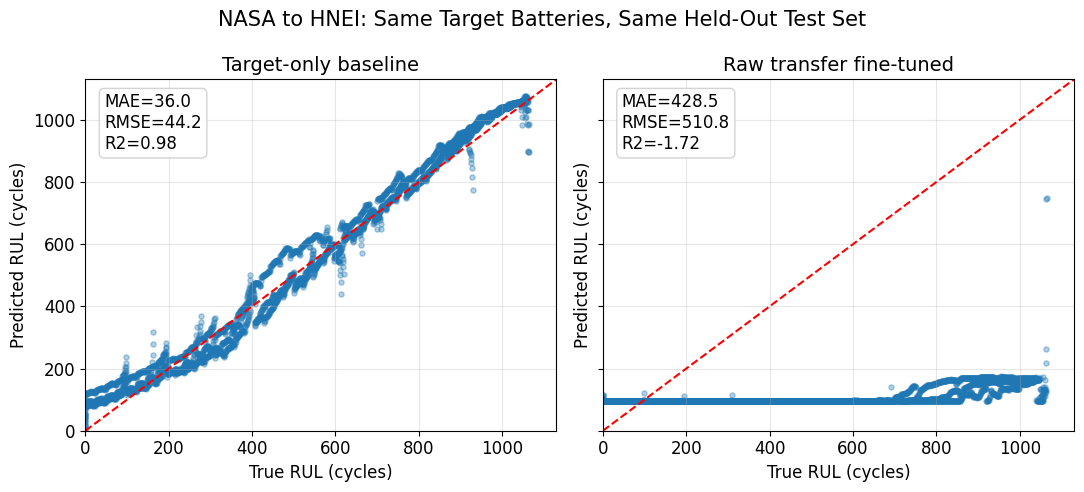

Saved scatter plot to figures/tft_raw_nasa_to_hnei_baseline_vs_transfer.png


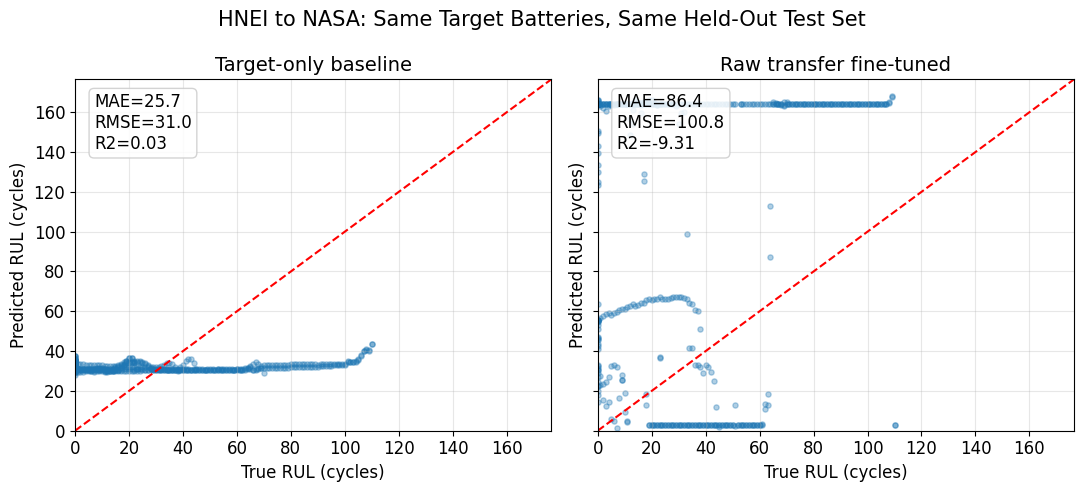

Saved scatter plot to figures/tft_raw_hnei_to_nasa_baseline_vs_transfer.png


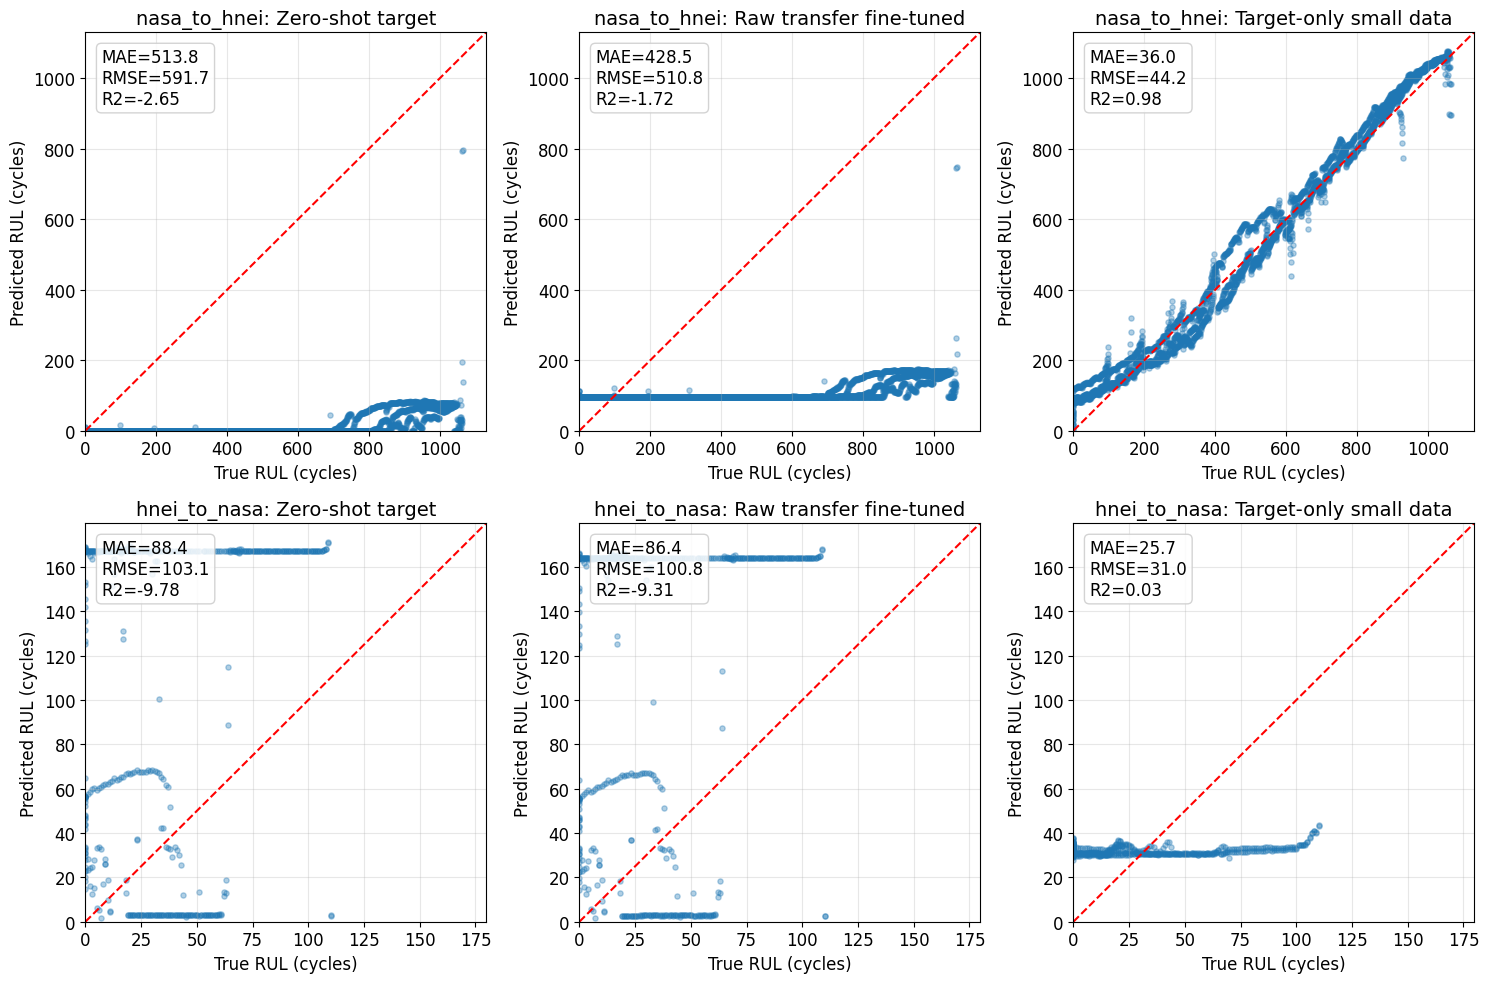

Saved scatter plot to figures/tft_raw_all_directions_scatter.png


In [11]:
def scatter_limits(metric_dicts: list[dict[str, object]]) -> tuple[float, float]:
    all_actuals = np.concatenate([metrics["actuals"] for metrics in metric_dicts])
    all_preds = np.concatenate([metrics["preds"] for metrics in metric_dicts])
    lower = float(min(all_actuals.min(), all_preds.min()))
    upper = float(max(all_actuals.max(), all_preds.max()))
    pad = 0.05 * (upper - lower) if upper > lower else 1.0
    return max(0.0, lower - pad), upper + pad


def annotate_metrics(ax, metrics: dict[str, object]) -> None:
    ax.text(
        0.04,
        0.96,
        f"MAE={metrics['mae']:.1f}\nRMSE={metrics['rmse']:.1f}\nR2={metrics['r2']:.2f}",
        transform=ax.transAxes,
        va="top",
        bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.8"},
    )


def plot_direction_baseline_vs_transfer(exp: dict[str, object]) -> Path:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    panels = [
        ("Target-only baseline", exp["target_only_metrics"]),
        ("Raw transfer fine-tuned", exp["transfer_metrics"]),
    ]
    lower, upper = scatter_limits([metrics for _, metrics in panels])

    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
    })
    fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
    for ax, (title, metrics) in zip(axes, panels):
        ax.scatter(metrics["actuals"], metrics["preds"], alpha=0.35, s=14)
        ax.plot([lower, upper], [lower, upper], "--", color="red", linewidth=1.5)
        ax.set_xlim(lower, upper)
        ax.set_ylim(lower, upper)
        ax.set_xlabel("True RUL (cycles)")
        ax.set_ylabel("Predicted RUL (cycles)")
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        annotate_metrics(ax, metrics)

    fig.suptitle(f"{exp['source_domain'].upper()} to {exp['target_domain'].upper()}: Same Target Batteries, Same Held-Out Test Set", fontsize=15)
    plt.tight_layout()
    path = FIGURE_DIR / f"tft_raw_{exp['direction']}_baseline_vs_transfer.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved scatter plot to {path}")
    return path


def plot_all_direction_scatter(experiments: list[dict[str, object]]) -> Path:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    panels = [
        ("Zero-shot target", "zero_shot_metrics"),
        ("Raw transfer fine-tuned", "transfer_metrics"),
        ("Target-only small data", "target_only_metrics"),
    ]
    fig, axes = plt.subplots(len(experiments), len(panels), figsize=(5 * len(panels), 5 * len(experiments)), squeeze=False)
    for row, exp in enumerate(experiments):
        lower, upper = scatter_limits([exp[key] for _, key in panels])
        for col, (title, key) in enumerate(panels):
            metrics = exp[key]
            ax = axes[row, col]
            ax.scatter(metrics["actuals"], metrics["preds"], alpha=0.35, s=14)
            ax.plot([lower, upper], [lower, upper], "--", color="red", linewidth=1.5)
            ax.set_xlim(lower, upper)
            ax.set_ylim(lower, upper)
            ax.set_xlabel("True RUL (cycles)")
            ax.set_ylabel("Predicted RUL (cycles)")
            ax.set_title(f"{exp['direction']}: {title}")
            ax.grid(True, alpha=0.3)
            annotate_metrics(ax, metrics)
    plt.tight_layout()
    path = FIGURE_DIR / "tft_raw_all_directions_scatter.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved scatter plot to {path}")
    return path


figure_paths = [plot_direction_baseline_vs_transfer(exp) for exp in experiments]
figure_paths.append(plot_all_direction_scatter(experiments))

## Final Run Summary

In [12]:
print("Final pipeline summary")
print(f"Order-based TFT window: min_encoder_length=1, max_encoder_length={MAX_ENCODER_LENGTH}, max_prediction_length={MAX_PREDICTION_LENGTH}")
print(f"Raw input feature count: {len(RAW_FEATURE_COLS)}")
print(f"Raw input features: {RAW_FEATURE_COLS}")
print("time_varying_known_reals: []")
print(f"Simulation batteries: {simulation_battery_ids}")

for exp in experiments:
    print("-" * 80)
    print(exp["direction"])
    print("  source feature scaler fit batteries:", list(exp["source_feature_scaler"]["fit_battery_ids"]))
    print("  target feature scaler fit batteries:", list(exp["target_feature_scaler"]["fit_battery_ids"]))
    print("  source target scaler fit batteries:", list(exp["source_scaler"]["fit_battery_ids"]))
    print("  target target scaler fit batteries:", list(exp["target_scaler"]["fit_battery_ids"]))
    print("  target simulation batteries:", exp["target_simulation_battery_ids"])
    print("  source TFT best/last:", exp["source_tft_best_checkpoint"], exp["source_tft_last_checkpoint"])
    print("  transfer TFT best/last:", exp["transfer_tft_best_checkpoint"], exp["transfer_tft_last_checkpoint"])
    print("  target-only TFT best/last:", exp["target_only_tft_best_checkpoint"], exp["target_only_tft_last_checkpoint"])

print("Saved CSVs:")
print(f"  metrics: {METRICS_CSV}")
print(f"  predictions: {PREDICTIONS_CSV}")
print("Saved scatter plots:")
for path in figure_paths:
    print(f"  {path}")
print("Checkpoint root:", CHECKPOINT_ROOT)

Final pipeline summary
Order-based TFT window: min_encoder_length=1, max_encoder_length=10, max_prediction_length=1
Raw input feature count: 7
Raw input features: ['discharge_time', 'decrement_36_34', 'max_voltage_discharge', 'min_voltage_charge', 'time_at_415', 'time_constant_current', 'charging_time']
time_varying_known_reals: []
Simulation batteries: {'hnei': 'hnei_13', 'nasa': 'nasa_33'}
--------------------------------------------------------------------------------
nasa_to_hnei
  source feature scaler fit batteries: ['nasa_00', 'nasa_01', 'nasa_04', 'nasa_05', 'nasa_06', 'nasa_07', 'nasa_09', 'nasa_10', 'nasa_14', 'nasa_16', 'nasa_17', 'nasa_18', 'nasa_22', 'nasa_23', 'nasa_25', 'nasa_28', 'nasa_29', 'nasa_30', 'nasa_31', 'nasa_32']
  target feature scaler fit batteries: ['hnei_01', 'hnei_07', 'hnei_10']
  source target scaler fit batteries: ['nasa_00', 'nasa_01', 'nasa_04', 'nasa_05', 'nasa_06', 'nasa_07', 'nasa_09', 'nasa_10', 'nasa_14', 'nasa_16', 'nasa_17', 'nasa_18', 'nasa_2